In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("Бібліотеки успішно підключені!")

Бібліотеки успішно підключені!


In [4]:
np.random.seed(42)

players = 500

player_id = []
for i in range(players):
    player_id.append(f"PLAYER-{1000+i}")

age = np.random.normal(loc=20, scale=5, size=players).astype(int)
hour = np.random.poisson(lam=120, size=players).astype(float)
matches = (hour * np.random.uniform(1.2, 2.5, size=players)).astype(int)
wins = (matches * np.random.uniform(0.3, 0.7, size=players)).astype(int)
kills = (matches * np.random.uniform(2, 10, size=players)).astype(int)
deaths = (matches * np.random.uniform(2, 8, size=players)).astype(int)
spend_money = np.random.exponential(scale=50, size=players).round(2)
ping = np.random.uniform(low=10, high=90, size=players).round(1)
ratings = np.random.randint(1, 11, size=players)

games_genre = {
    'CS GO': 'FPS',
    'DOTA': 'MOBA',
    'The Wincher': 'RPG', 
    'StarCraft': 'Strategy',
    'Rust': 'Survival'}

games = list(games_genre.keys())

select_games = np.random.choice(games, size=players)
select_genre = [games_genre[g] for g in select_games]

df = pd.DataFrame({
    'PlayerID': player_id,
    'Age': age,
    'Game': select_games,
    'Genre': select_genre,
    'HoursPlayed': hour,
    'MatchesPlayed': matches,
    'Wins': wins,
    'Kills': kills,
    'Deaths': deaths,
    'MoneySpent': spend_money,
    'Ping': ping,
    'Rating': ratings
})

In [5]:
df.loc[np.random.choice(df.index, 15, replace=False), 'Ping'] = np.nan
df.loc[np.random.choice(df.index, 10, replace=False), 'MoneySpent'] = np.nan

df.loc[5, 'HoursPlayed'] = 99999.0
df.loc[12, 'HoursPlayed'] = 85000.0

df.loc[25, 'Ping'] = -50.0
df.loc[88, 'Ping'] = 9999.0

df.loc[102, 'MoneySpent'] = 500000.0

df.loc[45, 'Age'] = -5
df.loc[130, 'Age'] = 150

print("--- Початковий датасет із помилками ---")
print(df.info())

--- Початковий датасет із помилками ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PlayerID       500 non-null    str    
 1   Age            500 non-null    int64  
 2   Game           500 non-null    str    
 3   Genre          500 non-null    str    
 4   HoursPlayed    500 non-null    float64
 5   MatchesPlayed  500 non-null    int64  
 6   Wins           500 non-null    int64  
 7   Kills          500 non-null    int64  
 8   Deaths         500 non-null    int64  
 9   MoneySpent     490 non-null    float64
 10  Ping           485 non-null    float64
 11  Rating         500 non-null    int32  
dtypes: float64(3), int32(1), int64(5), str(3)
memory usage: 45.1 KB
None


In [6]:
df_cleaned = df.copy()

hours_cap = df_cleaned['HoursPlayed'].quantile(0.99)
money_cap = df_cleaned['MoneySpent'].quantile(0.99)

valid_mask = (
    (df_cleaned['Age'] >= 6) & (df_cleaned['Age'] <= 100) &         
    (df_cleaned['Ping'] >= 0) & (df_cleaned['Ping'] <= 1000) &       
    (df_cleaned['Ping'].notna()) &                                    
    (df_cleaned['HoursPlayed'] <= hours_cap) &                        
    (df_cleaned['MoneySpent'].notna()) &                              
    (df_cleaned['MoneySpent'] <= money_cap)                          
)

df_cleaned = df_cleaned[valid_mask].reset_index(drop=True)

print(f"Видалено рядків із помилками: {len(df) - len(df_cleaned)}")
print(f"Залишилось некорумпованих записів: {len(df_cleaned)}")


Видалено рядків із помилками: 38
Залишилось некорумпованих записів: 462


In [7]:
print("Перші 5 рядків")
display(df_cleaned.head())

Перші 5 рядків


,PlayerID,Age,Game,Genre,HoursPlayed,MatchesPlayed,Wins,Kills,Deaths,MoneySpent,Ping,Rating
0,PLAYER-1000,22,StarCraft,Strategy,125.0,221,73,2065,1280,32.27,75.6,10
1,PLAYER-1001,19,CS GO,FPS,123.0,245,108,2353,720,26.19,76.1,1
2,PLAYER-1002,23,The Wincher,RPG,103.0,249,168,1647,1206,8.79,57.0,4
3,PLAYER-1003,27,CS GO,FPS,111.0,167,94,811,1051,53.42,38.2,7
4,PLAYER-1004,18,StarCraft,Strategy,109.0,148,84,1228,536,177.28,74.0,9


In [8]:
print("Останні 5 рядків")
display(df_cleaned.tail())

Останні 5 рядків


,PlayerID,Age,Game,Genre,HoursPlayed,MatchesPlayed,Wins,Kills,Deaths,MoneySpent,Ping,Rating
457,PLAYER-1495,22,DOTA,MOBA,123.0,206,65,1662,558,116.35,43.1,6
458,PLAYER-1496,14,CS GO,FPS,131.0,177,106,1199,1345,24.16,13.2,7
459,PLAYER-1497,19,Rust,Survival,105.0,183,82,1323,1116,12.19,31.9,10
460,PLAYER-1498,15,CS GO,FPS,140.0,304,138,2770,1577,29.22,86.5,1
461,PLAYER-1499,13,DOTA,MOBA,116.0,149,89,987,327,2.48,86.3,6


In [9]:
print("Випадкові 5 рядків")
display(df_cleaned.sample(5))

Випадкові 5 рядків


,PlayerID,Age,Game,Genre,HoursPlayed,MatchesPlayed,Wins,Kills,Deaths,MoneySpent,Ping,Rating
312,PLAYER-1340,15,The Wincher,RPG,104.0,129,39,577,856,57.32,85.4,2
97,PLAYER-1105,22,CS GO,FPS,112.0,155,58,941,975,46.12,73.9,7
249,PLAYER-1272,25,CS GO,FPS,115.0,235,100,844,988,45.93,29.9,2
324,PLAYER-1353,19,CS GO,FPS,111.0,197,99,1190,429,10.33,80.4,4
426,PLAYER-1460,29,CS GO,FPS,117.0,218,147,1410,1506,70.35,82.8,10


In [10]:
print("Загальна інформація")
df_cleaned.info()

Загальна інформація
<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PlayerID       462 non-null    str    
 1   Age            462 non-null    int64  
 2   Game           462 non-null    str    
 3   Genre          462 non-null    str    
 4   HoursPlayed    462 non-null    float64
 5   MatchesPlayed  462 non-null    int64  
 6   Wins           462 non-null    int64  
 7   Kills          462 non-null    int64  
 8   Deaths         462 non-null    int64  
 9   MoneySpent     462 non-null    float64
 10  Ping           462 non-null    float64
 11  Rating         462 non-null    int32  
dtypes: float64(3), int32(1), int64(5), str(3)
memory usage: 41.6 KB


In [11]:
print("Описова інформація")
display(df_cleaned.describe())

Описова інформація


,Age,HoursPlayed,MatchesPlayed,Wins,Kills,Deaths,MoneySpent,Ping,Rating
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,19.575758,119.619048,221.865801,110.705628,1333.045455,1104.781385,46.307814,50.093939,5.709957
std,4.977792,11.034255,48.691327,36.030295,593.384082,479.379672,44.366862,23.061315,2.976092
min,6.000000,88.000000,129.000000,39.000000,342.000000,293.000000,0.000000,10.000000,1.000000
25%,16.000000,111.000000,180.250000,84.000000,844.500000,725.000000,13.312500,29.725000,3.000000
50%,20.000000,120.000000,223.000000,106.500000,1233.500000,1054.500000,32.500000,50.350000,6.000000
75%,23.000000,127.000000,258.000000,136.000000,1797.750000,1426.000000,62.717500,71.025000,8.000000
max,39.000000,153.000000,347.000000,221.000000,3018.000000,2487.000000,231.950000,89.700000,10.000000


In [12]:
print("Кількість рядків")
print(df_cleaned.shape[0])

Кількість рядків
462


In [13]:
print("Кількість стовпців")
print(df_cleaned.shape[1])

Кількість стовпців
12


In [14]:
print("Типи стовпців")
print(df_cleaned.dtypes)

Типи стовпців
PlayerID             str
Age                int64
Game                 str
Genre                str
HoursPlayed      float64
MatchesPlayed      int64
Wins               int64
Kills              int64
Deaths             int64
MoneySpent       float64
Ping             float64
Rating             int32
dtype: object


In [15]:
print("Кількість пропущених значень")
print(df_cleaned.isna().sum())

Кількість пропущених значень
PlayerID         0
Age              0
Game             0
Genre            0
HoursPlayed      0
MatchesPlayed    0
Wins             0
Kills            0
Deaths           0
MoneySpent       0
Ping             0
Rating           0
dtype: int64


In [16]:
print("Кількість унікальних ігор")
print(df_cleaned["Game"].nunique())

Кількість унікальних ігор
5


In [17]:
print("Кількість гравців у кожній грі")
print(df_cleaned["Game"].value_counts())

Кількість гравців у кожній грі
Game
StarCraft      95
The Wincher    94
Rust           94
DOTA           93
CS GO          86
Name: count, dtype: int64


In [18]:
df_cleaned["WinRate"] = (df_cleaned["Wins"]/df_cleaned["MatchesPlayed"]* 100).round(2)

In [19]:
df_cleaned["KillDeath"] = (df_cleaned["Kills"]/df_cleaned["Deaths"]).round(2)

In [20]:
df_cleaned['HoursPerMatch'] = (df_cleaned['HoursPlayed'] / df_cleaned['MatchesPlayed']).fillna(0).round(2)

In [21]:
display(df_cleaned[['PlayerID', 'Game', 'WinRate', 'KillDeath', 'HoursPerMatch']].head())

,PlayerID,Game,WinRate,KillDeath,HoursPerMatch
0,PLAYER-1000,StarCraft,33.03,1.61,0.57
1,PLAYER-1001,CS GO,44.08,3.27,0.50
2,PLAYER-1002,The Wincher,67.47,1.37,0.41
3,PLAYER-1003,CS GO,56.29,0.77,0.66
4,PLAYER-1004,StarCraft,56.76,2.29,0.74


In [22]:
print("Середній вік гравців")
print(df_cleaned['Age'].mean())

Середній вік гравців
19.575757575757574


In [23]:
print("Медіанний вік")
print(df_cleaned['Age'].median())

Медіанний вік
20.0


In [24]:
print("Мода жанру")
print(df_cleaned['Genre'].mode()[0])

Мода жанру
Strategy


In [25]:
print("Середня кількість годин у грі")
print(df_cleaned['HoursPlayed'].mean())

Середня кількість годин у грі
119.61904761904762


In [26]:
print("Медіана HoursPlayed")
print(df_cleaned['HoursPlayed'].median())

Медіана HoursPlayed
120.0


In [27]:
print("Дисперсія HoursPlayed")
print(df_cleaned['HoursPlayed'].var())

Дисперсія HoursPlayed
121.75477739902902


In [28]:
print("Стандартне відхилення HoursPlayed")
print(df_cleaned['HoursPlayed'].std())

Стандартне відхилення HoursPlayed
11.034254727847687


In [29]:
print("Середній Ping")
print(df_cleaned['Ping'].mean())

Середній Ping
50.093939393939394


In [30]:
print("Середній KillDeath:")
print(df_cleaned['KillDeath'].mean())

Середній KillDeath:
1.3855194805194806


In [31]:
print("Середній WinRate:")
print(df_cleaned['WinRate'].mean())

Середній WinRate:
49.81088744588744


In [32]:
print("Середня кількість витрачених грошей:")
print(df_cleaned['MoneySpent'].mean())

Середня кількість витрачених грошей:
46.30781385281385


In [33]:
print("Загальна сума грошей, витрачена всіма гравцями:")
print(df_cleaned['MoneySpent'].sum())

Загальна сума грошей, витрачена всіма гравцями:
21394.21


In [34]:
top_player_hour  = df_cleaned.loc[df_cleaned['HoursPlayed'].idxmax()]
print(f"Найбільше годин: {top_player_hour['PlayerID']} ({top_player_hour['HoursPlayed']} год)")

Найбільше годин: PLAYER-1240 (153.0 год)


In [35]:
top_player_kills  = df_cleaned.loc[df_cleaned['Kills'].idxmax()]
print(f"Найбільше вбивств: {top_player_kills['PlayerID']} ({top_player_kills['Kills']})")

Найбільше вбивств: PLAYER-1286 (3018)


In [36]:
top_player_kd  = df_cleaned.loc[df_cleaned['KillDeath'].idxmax()]
print(f"Найкращий KD: {top_player_kd['PlayerID']} ({top_player_kd['KillDeath']})")

Найкращий KD: PLAYER-1452 (4.45)


In [37]:
top_winrate  = df_cleaned.loc[df_cleaned['WinRate'].idxmax()]
print(f"Найбільший WinRate: {top_winrate['PlayerID']} ({top_winrate['WinRate']})")

Найбільший WinRate: PLAYER-1187 (69.77)


In [38]:
top_player_money  = df_cleaned.loc[df_cleaned['MoneySpent'].idxmax()]
print(f"Найбільше витрачено грошей: {top_player_money['PlayerID']} ({top_player_money['MoneySpent']})")

Найбільше витрачено грошей: PLAYER-1082 (231.95)


In [39]:
top_player_ping  = df_cleaned.loc[df_cleaned['Ping'].idxmax()]
print(f"Найбільший пінг: {top_player_ping['PlayerID']} ({top_player_ping['Ping']})")

Найбільший пінг: PLAYER-1120 (89.7)


In [40]:
cols_to_show = ['PlayerID', 'Game', 'Genre', 'HoursPlayed', 'Kills', 'KillDeath', 'WinRate', 'MoneySpent']

print("\nТОП-10 HoursPlayed")
display(df_cleaned.nlargest(10, 'HoursPlayed')[cols_to_show])

print("\nТОП-10 Kills")
display(df_cleaned.nlargest(10, 'Kills')[cols_to_show])

print("\nТОП-10 KD")
display(df_cleaned.nlargest(10, 'KillDeath')[cols_to_show])

print("\nТОП-10 MoneySpent")
display(df_cleaned.nlargest(10, 'MoneySpent')[cols_to_show])


ТОП-10 HoursPlayed


,PlayerID,Game,Genre,HoursPlayed,Kills,KillDeath,WinRate,MoneySpent
219,PLAYER-1240,DOTA,MOBA,153.0,995,0.87,49.82,49.09
281,PLAYER-1305,CS GO,FPS,153.0,1862,1.60,50.00,25.71
347,PLAYER-1376,Rust,Survival,149.0,2689,1.67,63.69,58.45
429,PLAYER-1463,DOTA,MOBA,148.0,1215,0.61,68.77,4.18
333,PLAYER-1362,The Wincher,RPG,146.0,2335,0.96,60.63,5.72
132,PLAYER-1144,StarCraft,Strategy,145.0,750,0.58,49.20,5.01
211,PLAYER-1232,CS GO,FPS,145.0,2298,0.92,38.94,57.37
349,PLAYER-1378,The Wincher,RPG,145.0,1872,1.51,65.69,18.39
138,PLAYER-1150,The Wincher,RPG,143.0,1830,0.88,60.35,69.81
163,PLAYER-1179,CS GO,FPS,143.0,1502,1.13,35.27,13.76



ТОП-10 Kills


,PlayerID,Game,Genre,HoursPlayed,Kills,KillDeath,WinRate,MoneySpent
263,PLAYER-1286,Rust,Survival,134.0,3018,1.42,49.68,17.54
58,PLAYER-1064,DOTA,MOBA,122.0,2915,1.37,44.30,36.09
126,PLAYER-1137,Rust,Survival,128.0,2860,2.21,61.43,27.77
460,PLAYER-1498,CS GO,FPS,140.0,2770,1.76,45.39,29.22
104,PLAYER-1112,The Wincher,RPG,118.0,2754,1.22,53.06,13.16
347,PLAYER-1376,Rust,Survival,149.0,2689,1.67,63.69,58.45
10,PLAYER-1011,StarCraft,Strategy,122.0,2616,1.85,64.64,139.42
326,PLAYER-1355,DOTA,MOBA,124.0,2595,1.50,42.36,16.74
228,PLAYER-1249,StarCraft,Strategy,109.0,2579,3.16,61.80,20.88
150,PLAYER-1163,StarCraft,Strategy,135.0,2555,1.51,34.24,15.61



ТОП-10 KD


,PlayerID,Game,Genre,HoursPlayed,Kills,KillDeath,WinRate,MoneySpent
420,PLAYER-1452,DOTA,MOBA,131.0,1539,4.45,47.47,25.23
408,PLAYER-1440,The Wincher,RPG,117.0,1874,4.29,68.87,11.71
99,PLAYER-1107,Rust,Survival,124.0,2063,4.09,43.58,13.32
318,PLAYER-1347,The Wincher,RPG,131.0,2244,3.93,45.93,60.30
42,PLAYER-1046,StarCraft,Strategy,107.0,1943,3.80,58.08,49.69
301,PLAYER-1326,CS GO,FPS,120.0,2020,3.78,59.44,18.91
417,PLAYER-1449,Rust,Survival,106.0,1488,3.76,69.09,4.13
372,PLAYER-1402,DOTA,MOBA,99.0,1736,3.73,54.82,26.58
261,PLAYER-1284,Rust,Survival,100.0,1491,3.69,33.17,56.91
64,PLAYER-1070,CS GO,FPS,131.0,2554,3.67,49.39,0.32



ТОП-10 MoneySpent


,PlayerID,Game,Genre,HoursPlayed,Kills,KillDeath,WinRate,MoneySpent
76,PLAYER-1082,Rust,Survival,99.0,1097,0.71,41.18,231.95
176,PLAYER-1193,CS GO,FPS,125.0,867,1.52,63.11,222.93
304,PLAYER-1329,Rust,Survival,109.0,571,1.78,45.71,218.45
448,PLAYER-1485,The Wincher,RPG,125.0,921,1.26,33.33,202.34
205,PLAYER-1225,StarCraft,Strategy,120.0,1788,1.62,40.76,193.52
65,PLAYER-1071,StarCraft,Strategy,115.0,1878,2.34,31.09,191.65
177,PLAYER-1194,Rust,Survival,102.0,747,1.54,59.12,189.23
102,PLAYER-1110,CS GO,FPS,134.0,2044,1.27,52.08,183.83
119,PLAYER-1128,Rust,Survival,113.0,701,2.39,38.85,182.10
4,PLAYER-1004,StarCraft,Strategy,109.0,1228,2.29,56.76,177.28


In [41]:
print("Кількість гравців:")
print(df_cleaned.groupby('Game')['PlayerID'].count())

Кількість гравців:
Game
CS GO          86
DOTA           93
Rust           94
StarCraft      95
The Wincher    94
Name: PlayerID, dtype: int64


In [42]:
print("Середній вік:")
print(df_cleaned.groupby('Game')['Age'].mean().round())

Середній вік:
Game
CS GO          20.0
DOTA           19.0
Rust           20.0
StarCraft      19.0
The Wincher    19.0
Name: Age, dtype: float64


In [43]:
print("Середня кількість годин:")
print(df_cleaned.groupby('Game')['HoursPlayed'].mean().round(1))

Середня кількість годин:
Game
CS GO          119.9
DOTA           120.1
Rust           118.2
StarCraft      119.6
The Wincher    120.4
Name: HoursPlayed, dtype: float64


In [44]:
print("Середня кількість матчів:")
print(df_cleaned.groupby('Game')['MatchesPlayed'].mean().round(1))

Середня кількість матчів:
Game
CS GO          224.1
DOTA           219.8
Rust           222.4
StarCraft      215.7
The Wincher    227.6
Name: MatchesPlayed, dtype: float64


In [45]:
print("Середній KD:")
print(df_cleaned.groupby('Game')['KillDeath'].mean().round(2))

Середній KD:
Game
CS GO          1.43
DOTA           1.36
Rust           1.37
StarCraft      1.42
The Wincher    1.36
Name: KillDeath, dtype: float64


In [46]:
print("Середній WinRate (%):")
print(df_cleaned.groupby('Game')['WinRate'].mean().round(2))

Середній WinRate (%):
Game
CS GO          49.04
DOTA           50.37
Rust           50.26
StarCraft      47.86
The Wincher    51.49
Name: WinRate, dtype: float64


In [47]:
print("Середній Ping:")
print(df_cleaned.groupby('Game')['Ping'].mean().round(1))

Середній Ping:
Game
CS GO          51.5
DOTA           50.2
Rust           47.2
StarCraft      50.4
The Wincher    51.4
Name: Ping, dtype: float64


In [48]:
print("Середній Rating:")
print(df_cleaned.groupby('Game')['Rating'].mean().round(2))

Середній Rating:
Game
CS GO          5.34
DOTA           5.91
Rust           5.89
StarCraft      5.43
The Wincher    5.95
Name: Rating, dtype: float64


In [49]:
print("Загальна сума витрачених грошей:")
print(df_cleaned.groupby('Game')['MoneySpent'].sum().round(2))

Загальна сума витрачених грошей:
Game
CS GO          4170.34
DOTA           4295.95
Rust           4646.29
StarCraft      4086.84
The Wincher    4194.79
Name: MoneySpent, dtype: float64


In [50]:
print("Найпопулярніша гра:", df_cleaned['Game'].value_counts().idxmax())

Найпопулярніша гра: StarCraft


In [51]:
print("Гра з найбільш активними гравцями:", df_cleaned.groupby('Game')['HoursPlayed'].mean().idxmax())

Гра з найбільш активними гравцями: The Wincher


In [52]:
print("Гра з найбільшими витратами користувачів:", df_cleaned.groupby('Game')['MoneySpent'].sum().idxmax())

Гра з найбільшими витратами користувачів: Rust


In [53]:
print("Гра з найкращим середнім рейтингом:", df_cleaned.groupby('Game')['Rating'].mean().idxmax())

Гра з найкращим середнім рейтингом: The Wincher


In [54]:
print("Гра з найкращим середнім WinRate:", df_cleaned.groupby('Game')['WinRate'].mean().idxmax())

Гра з найкращим середнім WinRate: The Wincher


In [55]:
print("Кількість гравців:")
print(df_cleaned.groupby('Genre')['PlayerID'].count())

Кількість гравців:
Genre
FPS         86
MOBA        93
RPG         94
Strategy    95
Survival    94
Name: PlayerID, dtype: int64


In [56]:
print("Середній час гри:")
print(df_cleaned.groupby('Genre')['HoursPlayed'].mean().round(1))

Середній час гри:
Genre
FPS         119.9
MOBA        120.1
RPG         120.4
Strategy    119.6
Survival    118.2
Name: HoursPlayed, dtype: float64


In [57]:
print("Середній KD:")
print(df_cleaned.groupby('Genre')['KillDeath'].mean().round(2))

Середній KD:
Genre
FPS         1.43
MOBA        1.36
RPG         1.36
Strategy    1.42
Survival    1.37
Name: KillDeath, dtype: float64


In [58]:
print("Середній WinRate:")
print(df_cleaned.groupby('Genre')['WinRate'].mean().round(2))

Середній WinRate:
Genre
FPS         49.04
MOBA        50.37
RPG         51.49
Strategy    47.86
Survival    50.26
Name: WinRate, dtype: float64


In [59]:
print("Середній рейтинг:")
print(df_cleaned.groupby('Genre')['Rating'].mean().round(2))

Середній рейтинг:
Genre
FPS         5.34
MOBA        5.91
RPG         5.95
Strategy    5.43
Survival    5.89
Name: Rating, dtype: float64


In [60]:
print("Середня кількість витрачених грошей:")
print(df_cleaned.groupby('Genre')['MoneySpent'].mean().round(2))

Середня кількість витрачених грошей:
Genre
FPS         48.49
MOBA        46.19
RPG         44.63
Strategy    43.02
Survival    49.43
Name: MoneySpent, dtype: float64


In [61]:
most_active_genre = df_cleaned.groupby('Genre')['HoursPlayed'].mean().idxmax()
print(f"Жанр з найбільш активною аудиторією — {most_active_genre}")

Жанр з найбільш активною аудиторією — RPG


In [62]:
corr_cols = [
    'Age', 'HoursPlayed', 'MatchesPlayed', 'Wins', 
    'Kills', 'Deaths', 'MoneySpent', 'Ping', 
    'Rating', 'KillDeath', 'WinRate'
]

corr_matrix = df_cleaned[corr_cols].corr().round(2)

print("Матриця кореляції")
display(corr_matrix)

corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0].sort_values(ascending=False)

top_pairs = corr_unstacked.iloc[::2].head(3)

for (var1, var2), val in top_pairs.items():
    real_corr = corr_matrix.loc[var1, var2]
    print(f"Пара: {var1} <-> {var2} | Коефіцієнт кореляції: {real_corr}")

Матриця кореляції


,Age,HoursPlayed,MatchesPlayed,Wins,Kills,Deaths,MoneySpent,Ping,Rating,KillDeath,WinRate
Age,1.00,-0.04,0.01,-0.01,0.02,-0.05,-0.05,-0.02,0.03,0.04,-0.04
HoursPlayed,-0.04,1.00,0.40,0.32,0.17,0.24,0.01,0.02,-0.01,-0.05,0.08
MatchesPlayed,0.01,0.40,1.00,0.69,0.48,0.57,-0.03,0.08,-0.06,-0.06,0.03
Wins,-0.01,0.32,0.69,1.00,0.30,0.37,-0.05,0.04,-0.03,-0.03,0.73
Kills,0.02,0.17,0.48,0.30,1.00,0.34,-0.03,0.09,-0.08,0.50,-0.03
Deaths,-0.05,0.24,0.57,0.37,0.34,1.00,0.01,0.00,-0.05,-0.54,-0.01
MoneySpent,-0.05,0.01,-0.03,-0.05,-0.03,0.01,1.00,0.06,0.08,-0.04,-0.04
Ping,-0.02,0.02,0.08,0.04,0.09,0.00,0.06,1.00,0.06,0.08,-0.03
Rating,0.03,-0.01,-0.06,-0.03,-0.08,-0.05,0.08,0.06,1.00,-0.00,0.02
KillDeath,0.04,-0.05,-0.06,-0.03,0.50,-0.54,-0.04,0.08,-0.00,1.00,0.01


Пара: Wins <-> WinRate | Коефіцієнт кореляції: 0.73
Пара: Wins <-> MatchesPlayed | Коефіцієнт кореляції: 0.69
Пара: Deaths <-> MatchesPlayed | Коефіцієнт кореляції: 0.57


In [65]:
younger_players = df_cleaned[df_cleaned['Age'] < 20]['HoursPlayed'].mean()
older_players = df_cleaned[df_cleaned['Age'] > 20]['HoursPlayed'].mean()

print(f"Середні години молодші: {younger_players:.1f} год")
print(f"Середні години старші: {older_players:.1f} год")


Середні години молодші: 120.0 год
Середні години старші: 119.2 год


In [66]:
median_hours = df_cleaned['HoursPlayed'].median()
print("Гравці з малим часом:", df_cleaned[df_cleaned['HoursPlayed'] < median_hours]['MoneySpent'].mean().round(2))
print("Гравці з великим часом:", df_cleaned[df_cleaned['HoursPlayed'] >= median_hours]['MoneySpent'].mean().round(2))

Гравці з малим часом: 44.87
Гравці з великим часом: 47.7


In [68]:
print("Низький пінг")
print("Середній KD:", df_cleaned[df_cleaned['Ping'] < 50]['KillDeath'].mean().round(2))
print("Середній WinRate:", df_cleaned[df_cleaned['Ping'] < 50]['WinRate'].mean().round(2))

print("Високий пінг")
print("Середній KD:", df_cleaned[df_cleaned['Ping'] >= 50]['KillDeath'].mean().round(2))
print("Середній WinRate:", df_cleaned[df_cleaned['Ping'] >= 50]['WinRate'].mean().round(2))

Низький пінг
Середній KD: 1.32
Середній WinRate: 50.31
Високий пінг
Середній KD: 1.45
Середній WinRate: 49.32


In [69]:
print("Гравці з малим часом:", df_cleaned[df_cleaned['HoursPlayed']<median_hours]['Rating'].mean().round(2))
print("Гравці з великим часом:", df_cleaned[df_cleaned['HoursPlayed']>median_hours]['Rating'].mean().round(2))


Гравці з малим часом: 5.77
Гравці з великим часом: 5.63


In [70]:
print("Ні, вік не впливає на ігрову активність. Усереднені показники годин гри в обох вікових групах майже однакові, суттєвої різниці у часі немає.")

print("Ні, витрати не залежать від проведеного часу. Гравці з малим часом витрачають у середньому $44.87, а з великим — $47.70, що є практично однаковим рівнем.")

print("Ні, рівень пінгу не погіршує результативність. У гравців із низьким пінгом середній KD становить 1.32, а WinRate — 50.31%, тоді як у гравців із високим пінгом KD — 1.45, а WinRate — 49.32%.")

print("Ні, кількість проведеного часу не підвищує суб'єктивну оцінку. Середній рейтинг гри серед гравців із малим часом становить 5.77, а серед гравців із великим часом — 5.63 (із 10).")


Ні, вік не впливає на ігрову активність. Усереднені показники годин гри в обох вікових групах майже однакові, суттєвої різниці у часі немає.
Ні, витрати не залежать від проведеного часу. Гравці з малим часом витрачають у середньому $44.87, а з великим — $47.70, що є практично однаковим рівнем.
Ні, рівень пінгу не погіршує результативність. У гравців із низьким пінгом середній KD становить 1.32, а WinRate — 50.31%, тоді як у гравців із високим пінгом KD — 1.45, а WinRate — 49.32%.
Ні, кількість проведеного часу не підвищує суб'єктивну оцінку. Середній рейтинг гри серед гравців із малим часом становить 5.77, а серед гравців із великим часом — 5.63 (із 10).


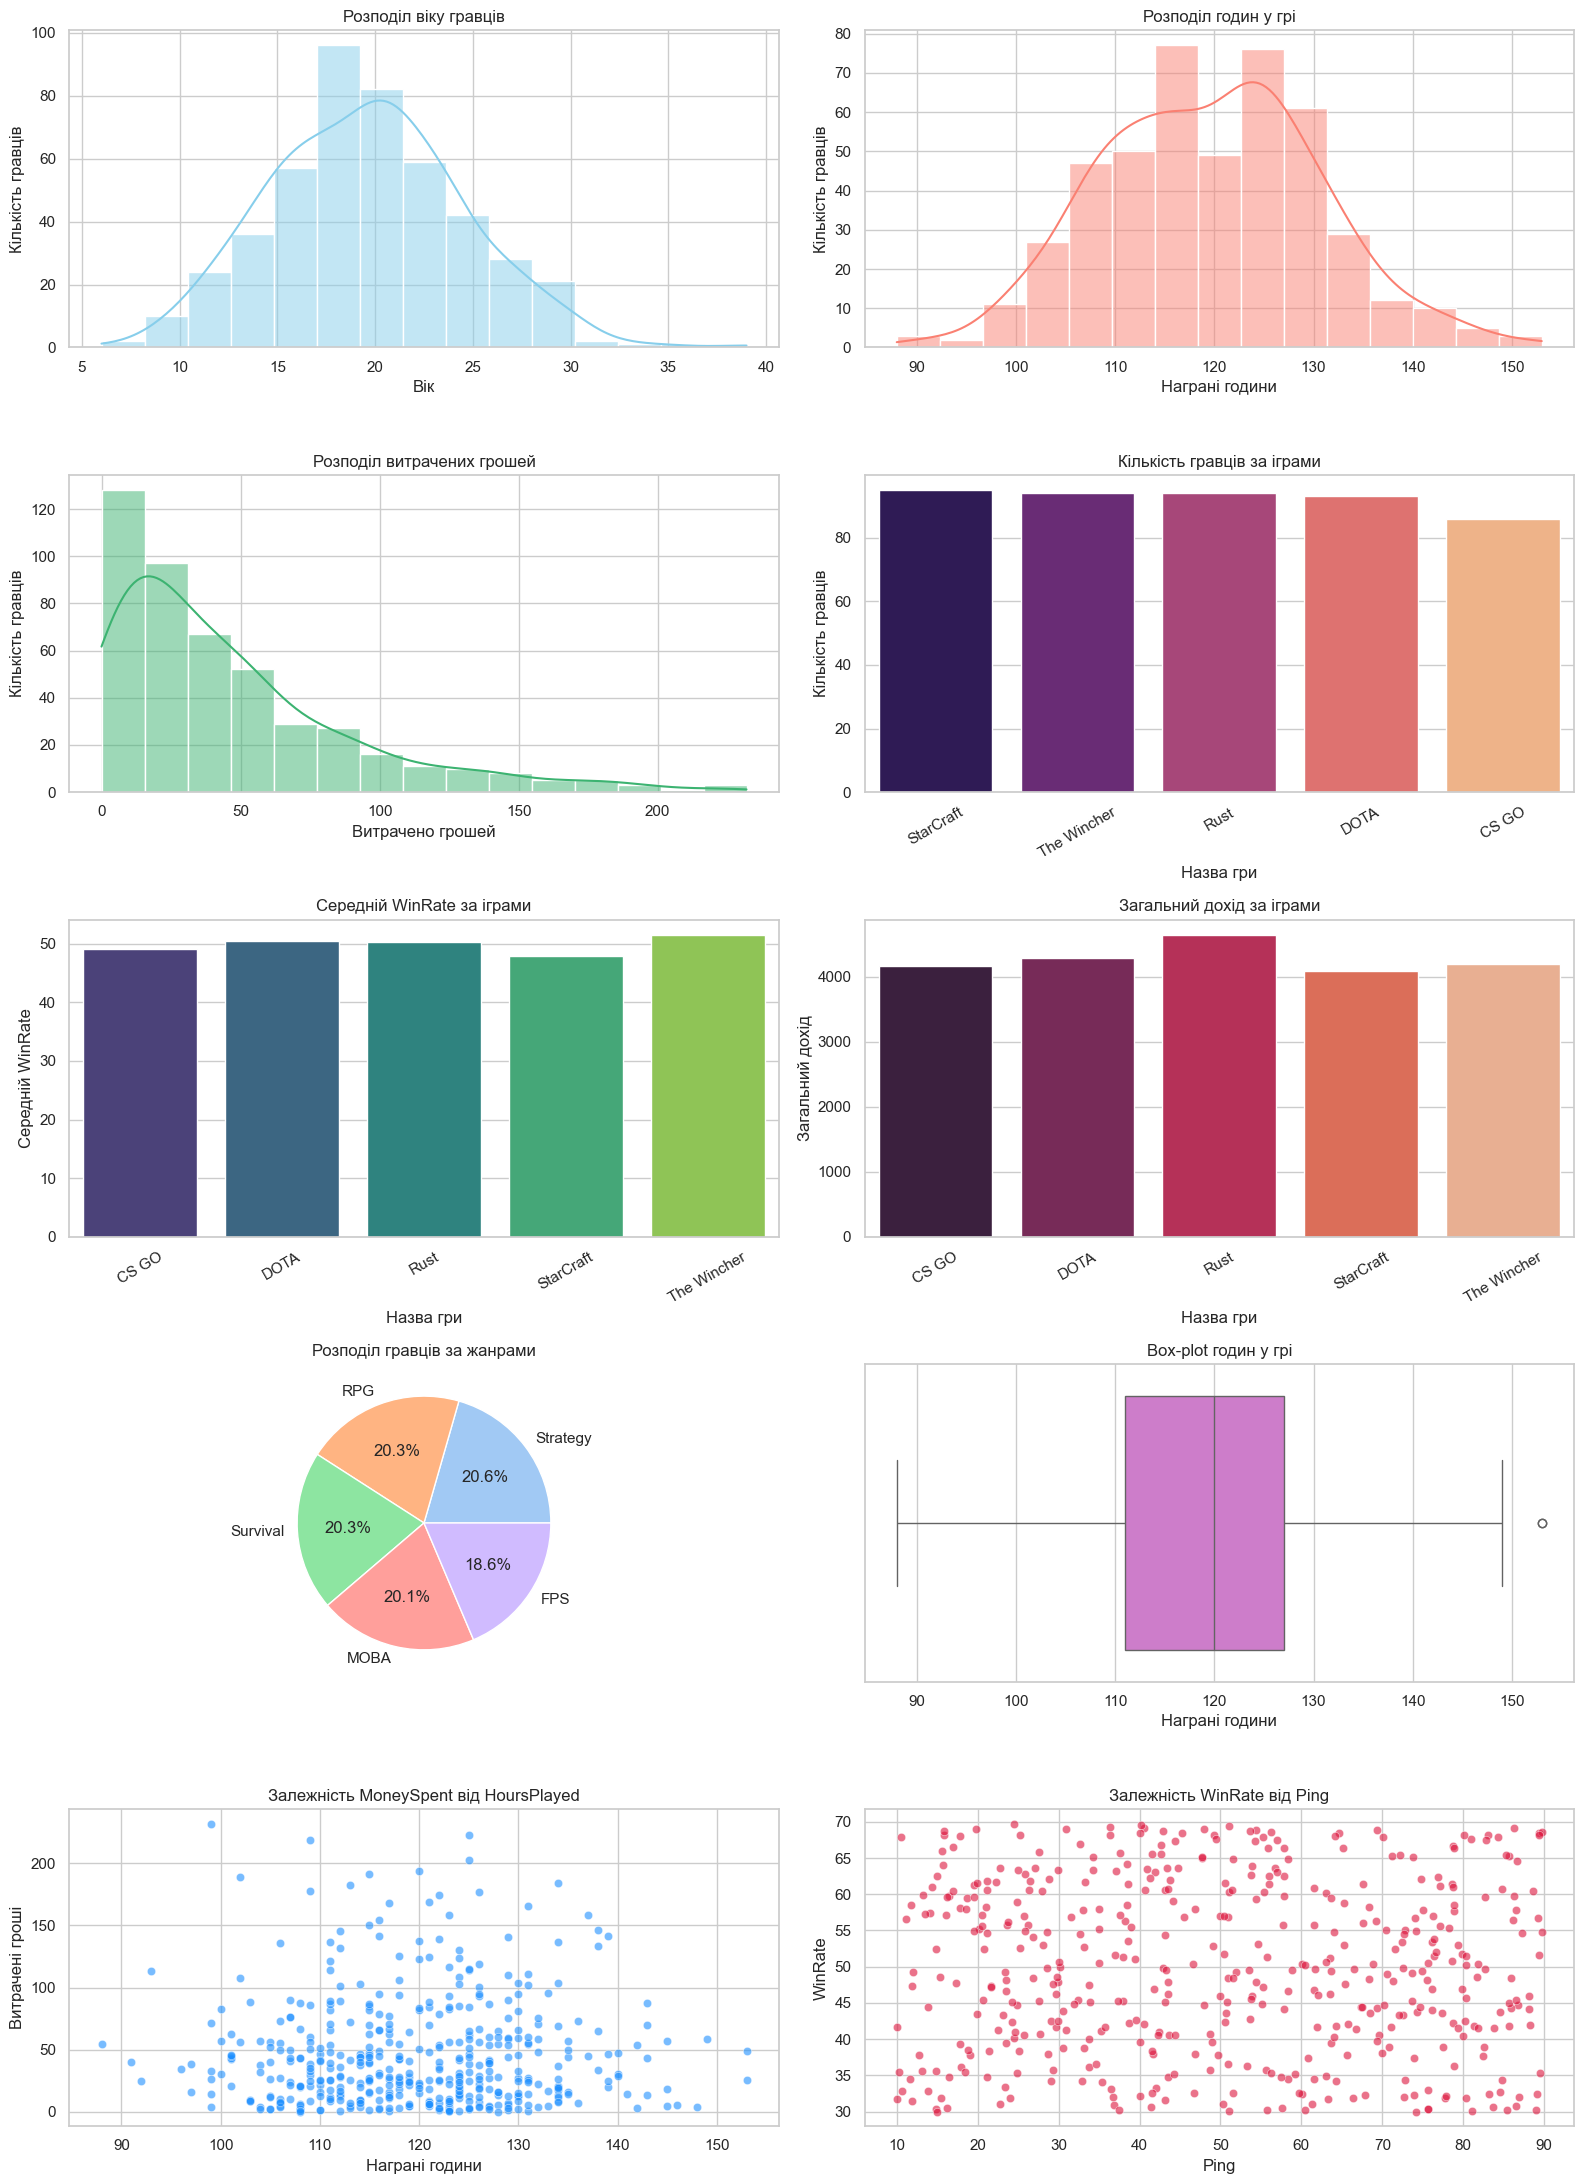

In [81]:
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

sns.histplot(df_cleaned['Age'], kde=True, color='skyblue', ax=axes[0, 0], bins=15)
axes[0, 0].set_title('Розподіл віку гравців')
axes[0, 0].set_xlabel('Вік')
axes[0, 0].set_ylabel('Кількість гравців')

sns.histplot(df_cleaned['HoursPlayed'], kde=True, color='salmon', ax=axes[0, 1], bins=15)
axes[0, 1].set_title('Розподіл годин у грі')
axes[0, 1].set_xlabel('Награні години')
axes[0, 1].set_ylabel('Кількість гравців')

sns.histplot(df_cleaned['MoneySpent'], kde=True, color='mediumseagreen', ax=axes[1, 0], bins=15)
axes[1, 0].set_title('Розподіл витрачених грошей')
axes[1, 0].set_xlabel('Витрачено грошей')
axes[1, 0].set_ylabel('Кількість гравців')

game_counts = df_cleaned['Game'].value_counts()
sns.barplot(
    x=game_counts.index, 
    y=game_counts.values, 
    ax=axes[1, 1], 
    hue=game_counts.index, 
    palette='magma', 
    legend=False
)
axes[1, 1].set_title('Кількість гравців за іграми')
axes[1, 1].set_xlabel('Назва гри')
axes[1, 1].set_ylabel('Кількість гравців')
axes[1, 1].tick_params(axis='x', rotation=30)

avg_winrate = df_cleaned.groupby('Game')['WinRate'].mean().reset_index()
sns.barplot(data=avg_winrate, x='Game', y='WinRate', ax=axes[2, 0], hue='Game', palette='viridis', legend=False)
axes[2, 0].set_title('Середній WinRate за іграми')
axes[2, 0].set_xlabel('Назва гри')
axes[2, 0].set_ylabel('Середній WinRate')
axes[2, 0].tick_params(axis='x', rotation=30)

total_money = df_cleaned.groupby('Game')['MoneySpent'].sum().reset_index()
sns.barplot(data=total_money, x='Game', y='MoneySpent', ax=axes[2, 1], hue='Game', palette='rocket', legend=False)
axes[2, 1].set_title('Загальний дохід за іграми')
axes[2, 1].set_xlabel('Назва гри')
axes[2, 1].set_ylabel('Загальний дохід')
axes[2, 1].tick_params(axis='x', rotation=30)

genre_counts = df_cleaned['Genre'].value_counts()
axes[3, 0].pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[3, 0].set_title('Розподіл гравців за жанрами')

sns.boxplot(x=df_cleaned['HoursPlayed'], color='orchid', ax=axes[3, 1])
axes[3, 1].set_title('Box-plot годин у грі')
axes[3, 1].set_xlabel('Награні години')

sns.scatterplot(data=df_cleaned, x='HoursPlayed', y='MoneySpent', alpha=0.6, color='dodgerblue', ax=axes[4, 0])
axes[4, 0].set_title('Залежність MoneySpent від HoursPlayed')
axes[4, 0].set_xlabel('Награні години')
axes[4, 0].set_ylabel('Витрачені гроші')

sns.scatterplot(data=df_cleaned, x='Ping', y='WinRate', alpha=0.6, color='crimson', ax=axes[4, 1])
axes[4, 1].set_title('Залежність WinRate від Ping')
axes[4, 1].set_xlabel('Ping')
axes[4, 1].set_ylabel('WinRate')

plt.tight_layout()
plt.show()